# Lab 5

Leonid Zinatullin

Used libraries:

In [1]:
import nidaqmx
import time

import numpy as np
import numpy.typing
from typing import Tuple

import matplotlib.pyplot as plt
from nidaqmx.constants import AcquisitionType, ProductCategory
from nidaqmx.constants import TerminalConfiguration
from nidaqmx.constants import AcquisitionType, READ_ALL_AVAILABLE, LineGrouping

import scipy as sp

# Task 1

In [ ]:
bottle_mass = 0.505 # kg

mean voltage:  0.003250 V
RMS noise:  0.000049 V


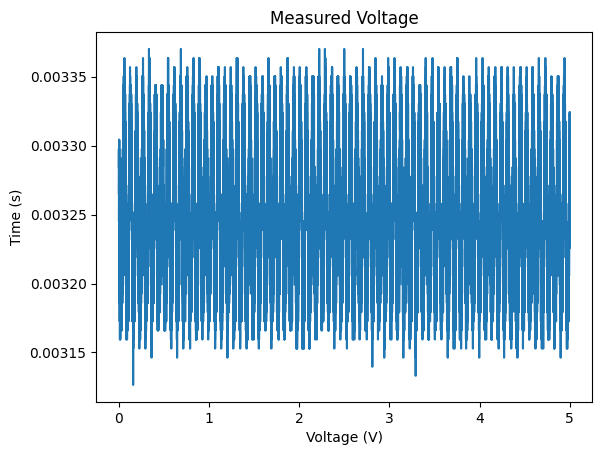

In [35]:


device_name = "/Dev7"
duration = 5 # seconds
rate = 10000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-0.2,
        max_val=0.2
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)
print(f"mean voltage: {np.mean(data): 3f} V")
print(f"RMS noise: {np.sqrt(np.mean(np.square(data - np.mean(data)))): 3f} V")

#PLOT DATA
plt.plot(np.linspace(0, duration, window_size), data)
plt.title('Measured Voltage')
plt.xlabel('Voltage (V)')
plt.ylabel('Time (s)')
plt.show()

|                      |                     | CONF #1   |                                          |             | CONF #2   |                                           |             |
|----------------------|---------------------|-----------|------------------------------------------|-------------|-----------|-------------------------------------------|-------------|
| DAQ mode             | Load                | DAQ range | Mean [loaded] mean [unloaded]            | Noise level | DAQ range | Mean [loaded] mean [unloaded]             | Noise level |
|                      | [g]                 | [土 V]    | [V]                                      | [V rms]     | [土 V]    | [V]                                       | [V rms]     |
| RSE   (half bridge)  | 0   Unloaded        | 5         | 1.486 - 1.484730                         | 0.000128    | .2        |                                           | 0.000048    |
|                      | (bottle) Loaded 505 |           | = -0.000295                              |             |           | $0.003095$   - $0.003250$   = -0.000155   |             |
| Diff   (full bridge) | 0 Unloaded          |           |                                          | 0.000023    |           |                                           | 0.000024    |
|                      | (bottle) Loaded 505 | .2        | $-0.000625$   - $-0.000320$   =-0.000305 |             | .2        | $-0.000627$   - $-0.000322$   = -0.000305 |             |

# Task 2


INA128:

min/max supply voltage range - 36V

bandwidth - G = 1, 1.3 MHz

noise levels - ca 8 nV Hz^-0.5

gain if the resistor Rg is not connected - 1



In [95]:
G = 1 + 50e3 / 1e2  # Gain of the amplifier circuit
G

501.0

| Measurement configuration | DAQ range | DAQ mode | INA gain   | Cutoff freq $(-3 \mathrm{~dB})$ | Sqrt of bandwidth       | Value    | Noise level | Noise density |
|---------------------------|-----------|----------|------------|---------------------------------|-------------------------|----------|-------------|---------------|
|                           | [土 V]    |          | (unitless) | [1/s]                           | [ $\mathrm{Hz}^{0.5}$ ] | [V mean] | [V rms]     | [nV/VHz]      |
| Whatever on the scale     | 0.2       | RSE      | 501        | Sampled at 100 kHz              | $\sqrt{ 450000} $       | 0.1553   | 0.0015      | 4.744         |
|                           |           |          |            | 1 … 100 Hz (1.5915)             | $\sqrt{ 3.2} $          | 0.1545   | 4.732e-05   | 27.32         |
|                           |           |          |            | $<0.5 \mathrm{~Hz}$ (0.1592)    | $\sqrt{ 0.32} $         | 0.1545   | 4.732e-05   | 83.65         |

In [106]:


device_name = "/Dev7"
duration = 5 # seconds
rate = 100000 # samples per second
window_size = duration * rate

with nidaqmx.Task() as task:
    task.ai_channels.add_ai_voltage_chan(
        device_name + "/ai0",
        terminal_config=TerminalConfiguration.RSE,
        min_val=-5.0,
        max_val=5.0
    )

    task.timing.cfg_samp_clk_timing(
        rate=rate,
        sample_mode=AcquisitionType.FINITE,
        samps_per_chan=window_size
    )

    data = task.read(number_of_samples_per_channel=window_size)
    data = np.array(data)


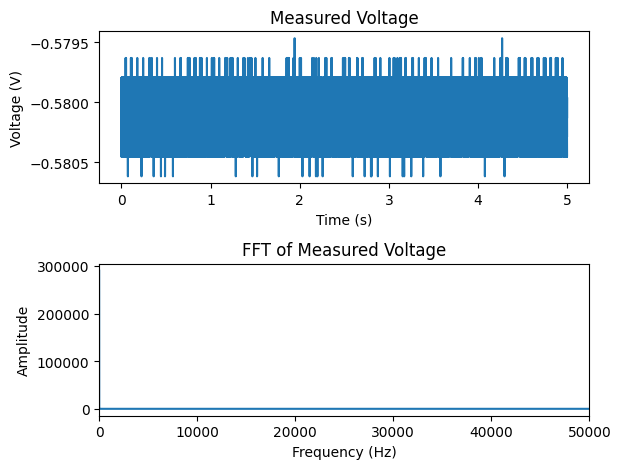

mean voltage: -0.5801 V
RMS noise:  0.0001118 V
Noise density:  0.3534 nV/√Hz


In [107]:

#multiplot with fourier transform
fft_data = np.fft.fft(data)
fft_freq = np.fft.fftfreq(len(data), 1/rate)
fig, axs = plt.subplots(2)
axs[0].plot(np.linspace(0, duration, window_size), data)
axs[0].set_title('Measured Voltage')
axs[0].set_xlabel('Time (s)')
axs[0].set_ylabel('Voltage (V)')
axs[1].plot(fft_freq[:len(fft_freq)//2], np.abs(fft_data)[:len(fft_data)//2])
axs[1].set_title('FFT of Measured Voltage')
axs[1].set_xlabel('Frequency (Hz)')
axs[1].set_ylabel('Amplitude')
axs[1].set_xlim(0, rate/2)
fig.tight_layout()
plt.show()

bandwidth = rate  # Bandwidth in Hz for white noise
noise_density = np.sqrt(np.mean(np.square(data - np.mean(data)))) / np.sqrt(bandwidth)
print(f"mean voltage: {np.mean(data): .4g} V")
print(f"RMS noise: {np.sqrt(np.mean(np.square(data - np.mean(data)))): .4g} V")
print(f"Noise density: {noise_density*1e6: .4g} nV/√Hz")

# Task 3



| INA gain                                                                       | DAQ range | Load   0 g (empty)   $\sim 1 \mathrm{~g}$ (nut)   $\sim 500 \mathrm{~g}$ (bottle) | Filter RxC | Value    | Noise level |
|--------------------------------------------------------------------------------|-----------|-----------------------------------------------------------------------------------|------------|----------|-------------|
| (unitless)                                                                     | [土 V]    | [g]                                                                               | [1/s]      | [V mean] | [V rms]     |
| $\mathrm{G}_{\text {Low }}$   $1 \leq G_{\text {Low }} \leq 10$                | 5         | 0                                                                                 | 7.2343     | -0.5792  | 0.0001215   |
| 3.27                                                                           |           | 1                                                                                 |            | -0.5787  | 0.0001193   |
|                                                                                |           | 500                                                                               |            | -0.5783  | 0.0001326   |
| $\mathrm{G}_{\text {MED }}$   $50 \leq G_{\text {MED }} \leq 100$              |           | 0                                                                                 |            | -0.5782  | 0.0001246   |
| 51                                                                             |           | 1                                                                                 |            | -0.5782  | 0.0001291   |
|                                                                                |           | 500                                                                               |            | -0.5783  | 0.0001311   |
| $\mathrm{G}_{\mathrm{HIGH}}$   $500 \leq \mathrm{G}_{\mathrm{HIGH}} \leq 1000$ |           | 0                                                                                 |            | -0.5789  | 0.0001251   |
| 501                                                                            |           | 1                                                                                 |            | -0.5788  | 0.0001204   |
|                                                                                |           | 500                                                                               |            | -0.5789  | 0.0001292   |

# Tasks

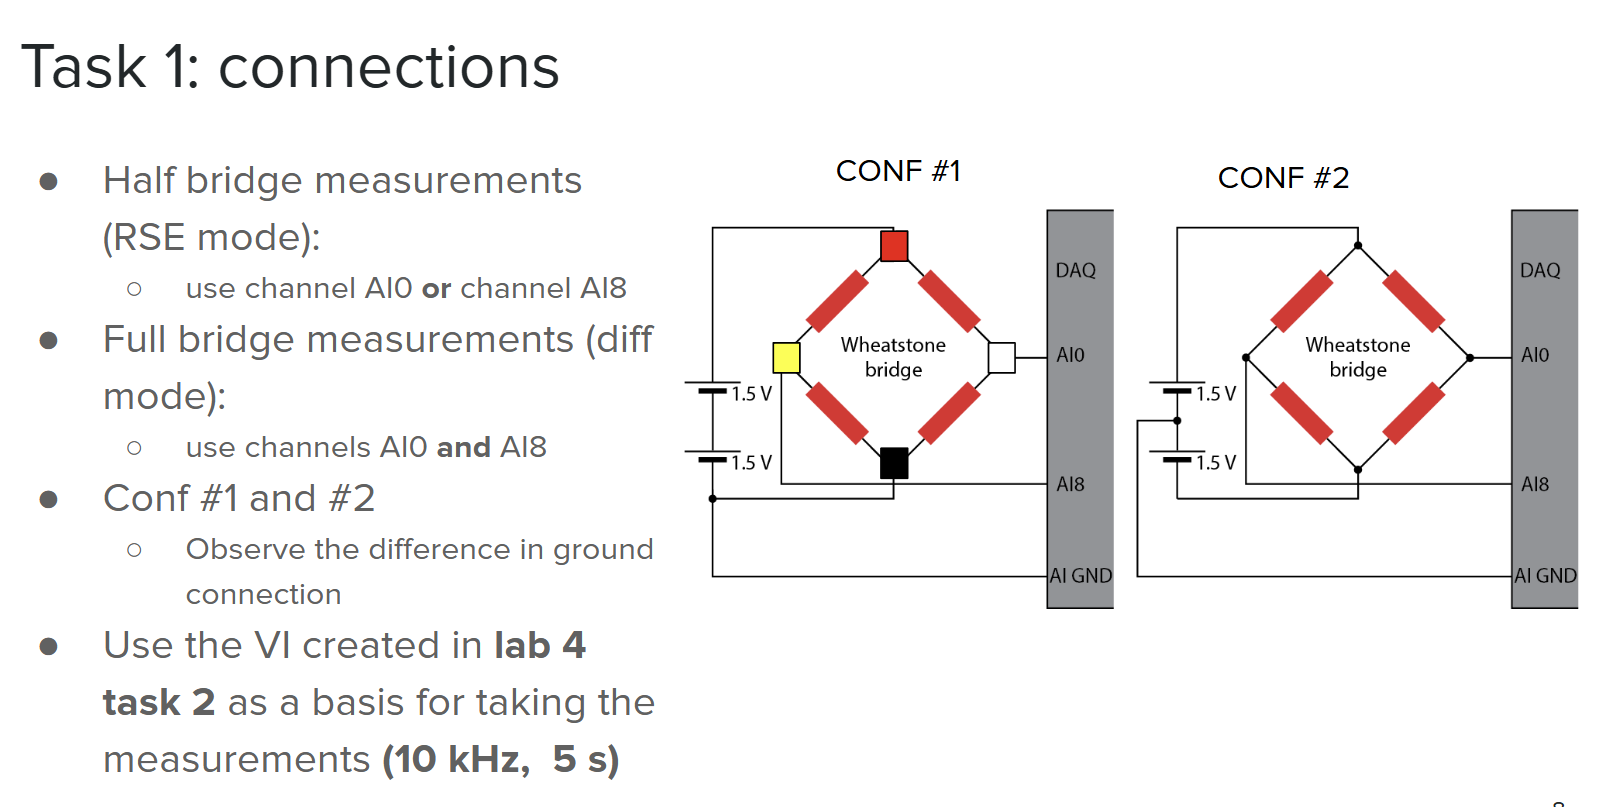

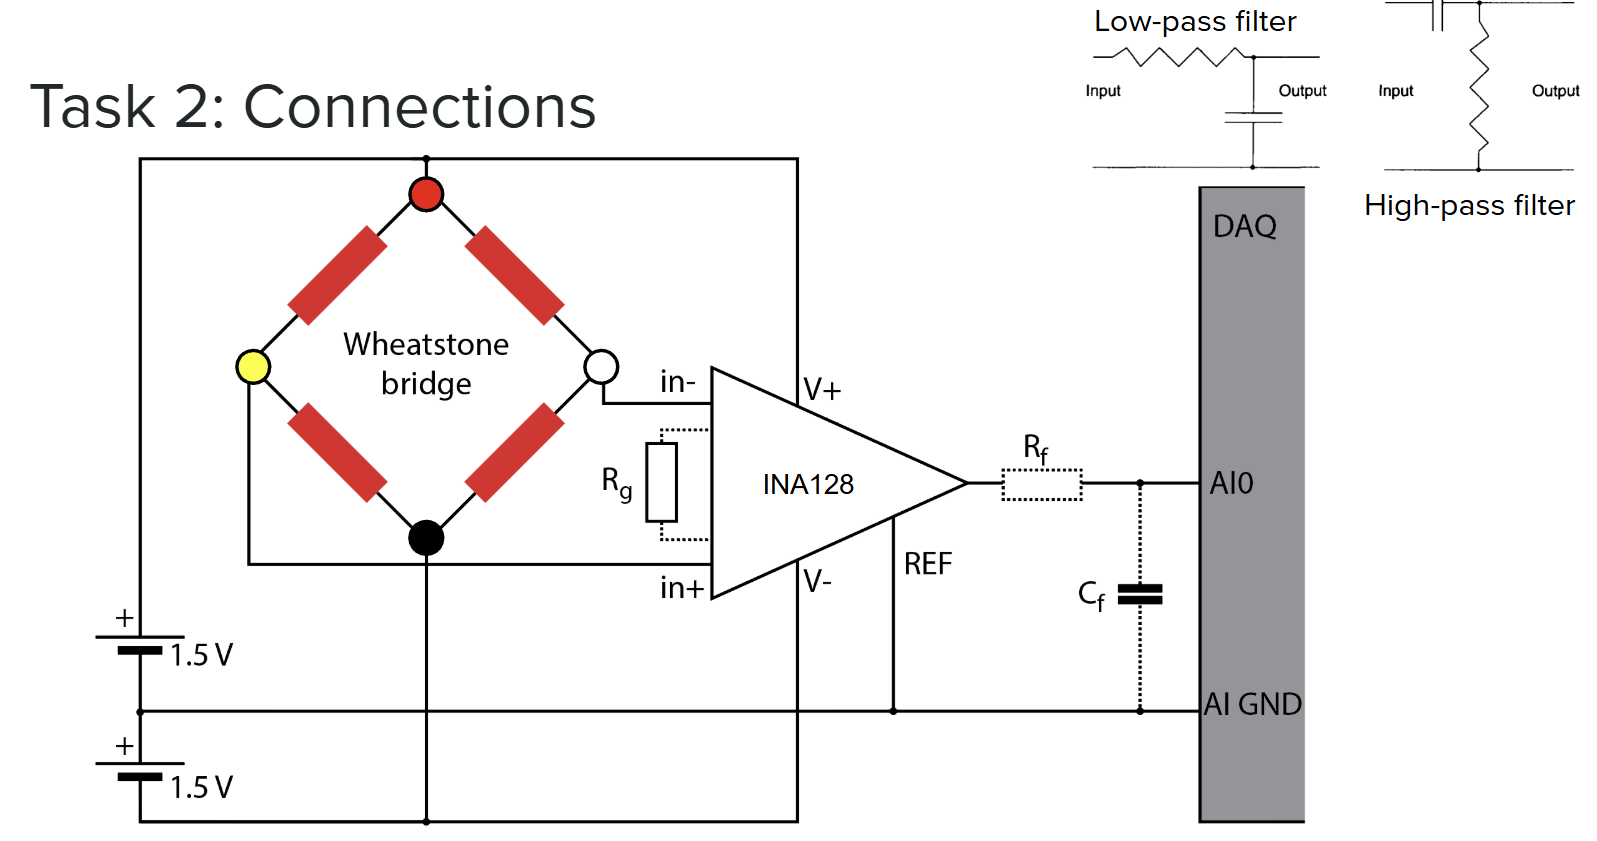
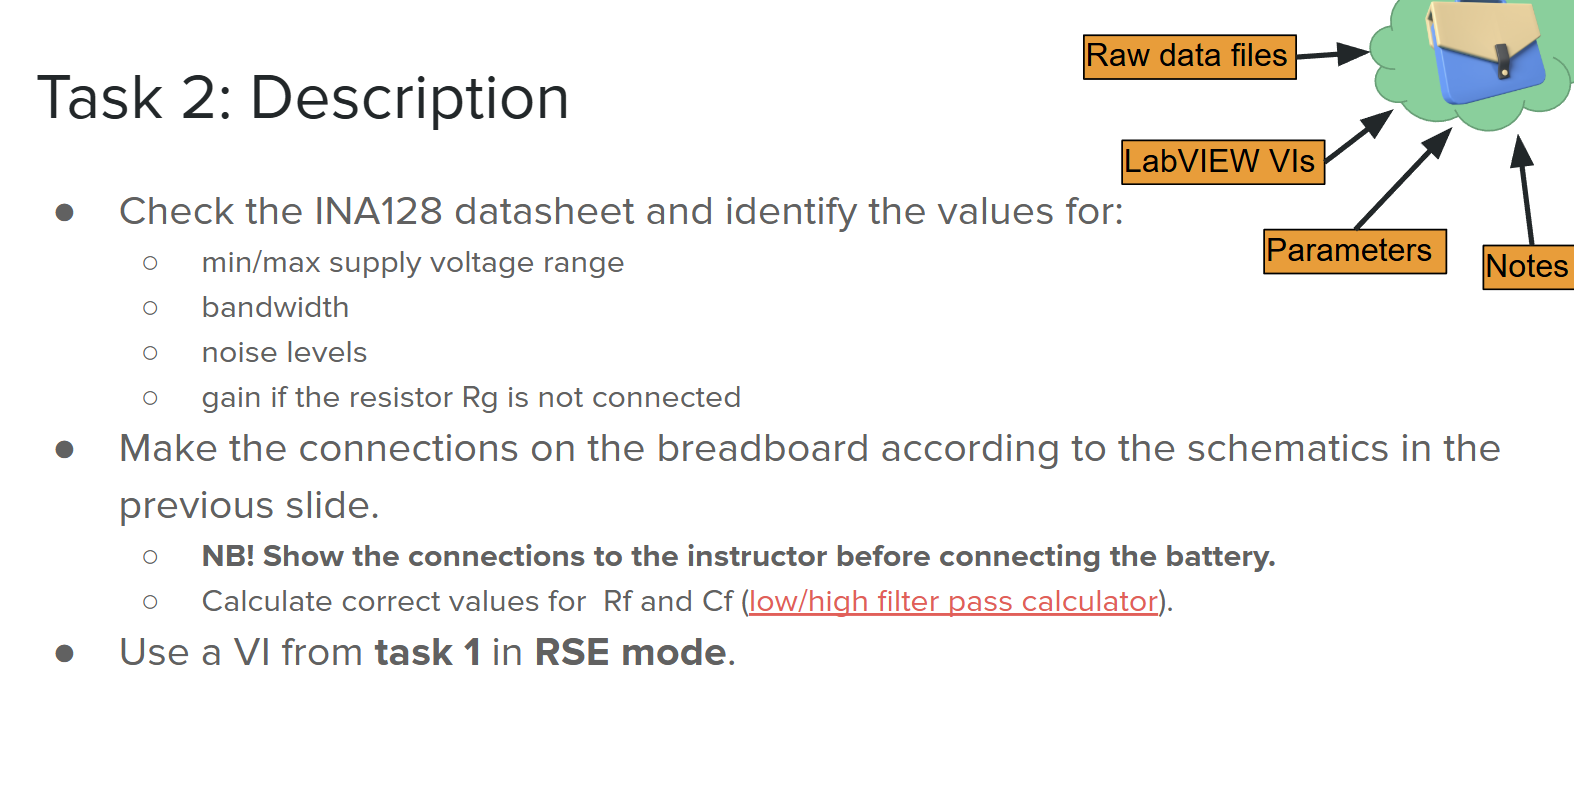

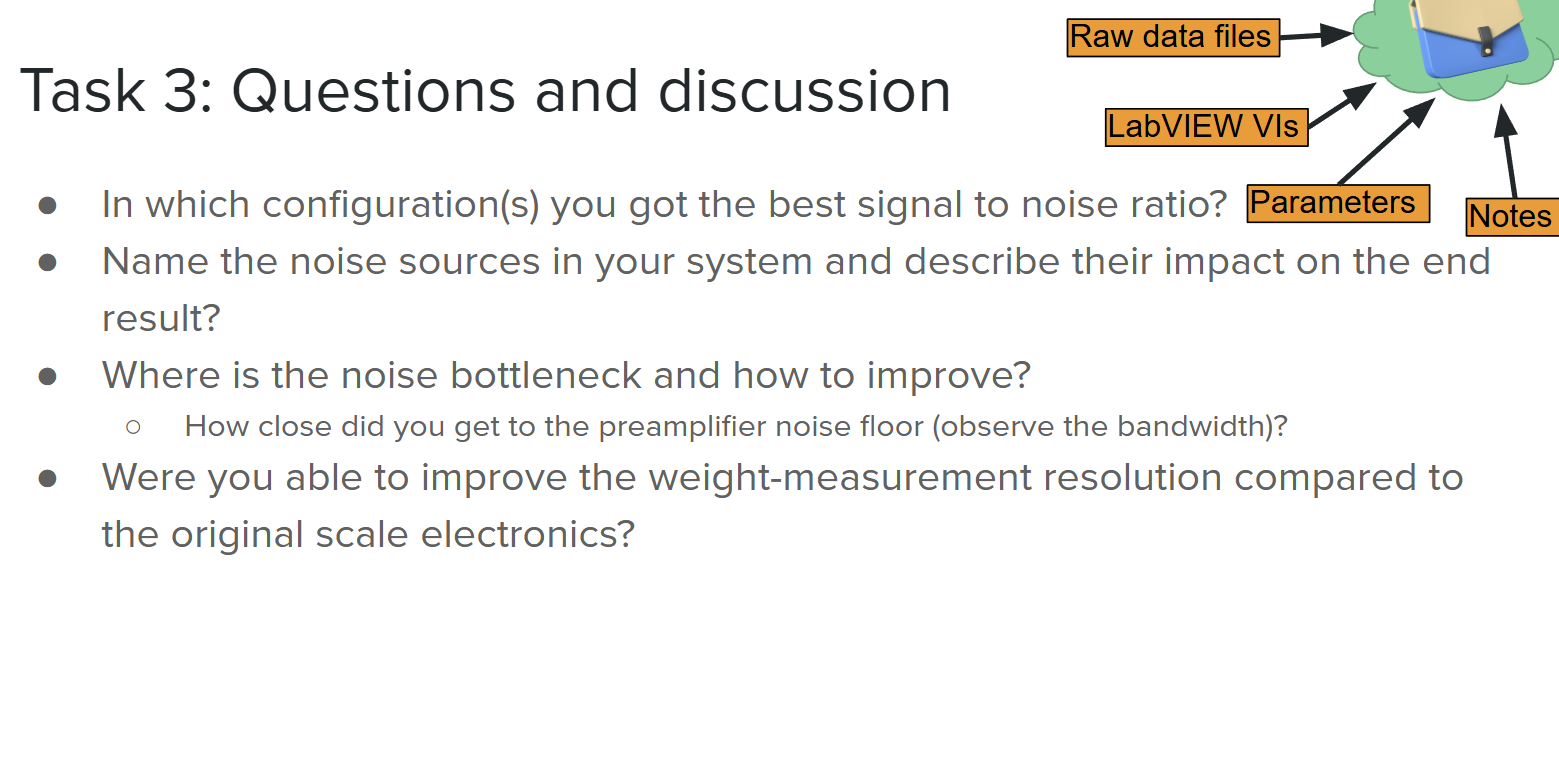